In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv('/home/matrament/projects/master_thesis/data/3way_junctions_features_graphs.csv')  # Wczytaj swój zbiór danych
X = dataset.drop(columns=['family', 'pdb_id','residues'])  
y = dataset['family'] 

In [3]:
print(f"Kształt danych: {X.shape}")
print(f"Liczba klas: {len(np.unique(y))}")
print(f"Rozkład klas:\n{pd.Series(y).value_counts()}")

Kształt danych: (111, 6)
Liczba klas: 3
Rozkład klas:
family
C    58
A    37
B    16
Name: count, dtype: int64


In [4]:
test_size=0.2
random_state=42
scaler = StandardScaler()
label_encoder = LabelEncoder()

# Kodowanie etykiet jeśli są stringami
if y.dtype == 'object':
    y = label_encoder.fit_transform(y)

# Podział na zbiory treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

# Normalizacja cech
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (88, 6)
Rozmiar zbioru testowego: (23, 6)


In [7]:
models = {
            'k-NN': KNeighborsClassifier(),
            'Random Forest': RandomForestClassifier(random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
            'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
            # 'SVM': SVC(probability=True),
            'LightGBM': lgb.LGBMClassifier(random_state=42,objective='multiclass', verbosity=-1)
        }

param_grids = {
            'k-NN': {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'SVM': {
                'C': [0.1, 1, 10, 100],
                'kernel': ['rbf', 'linear', 'poly'],
                'gamma': ['scale', 'auto']
            },
            'Random Forest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10]
            },
            'Logistic Regression': {
                'C': [0.01, 0.1, 1, 10],
                'penalty': ['l2', 'elasticnet'],
                'solver': ['lbfgs', 'saga'],
                'max_iter': [100, 200, 500]
            },
            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0]
            },
            'LightGBM': {
                'n_estimators': [100, 200],
                'learning_rate': [0.05, 0.1, 0.2],
                'num_leaves': [31, 63],
                'max_depth': [6, 9]
            }
            # 'LightGBM': {
            #     'n_estimators': [50, 100, 200],
            #     'max_depth': [3, 6, 9, -1],  # -1 oznacza brak limitu
            #     'learning_rate': [0.01, 0.05, 0.1, 0.2],
            #     'num_leaves': [15, 31, 63, 127],  # powinno być < 2^max_depth
            #     'min_child_samples': [10, 20, 30],
            #     'subsample': [0.7, 0.8, 0.9, 1.0],
            #     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            #     'reg_alpha': [0, 0.1, 0.5],  # L1 regularization
            #     'reg_lambda': [0, 0.1, 0.5]  # L2 regularization
            # }
        }

best_models = {}
        
for name, model in models.items():
    print(f"Dostrajanie hiperparametrów dla {name}...")
    
    grid_search = GridSearchCV(
        model, param_grids[name], 
        cv=10, scoring='balanced_accuracy', 
        n_jobs=-1, verbose=0
    )
    
    grid_search.fit(X, y)
    best_models[name] = grid_search.best_estimator_
    
    print(f"Najlepsze parametry dla {name}: {grid_search.best_params_}")
    print(f"Najlepszy wynik CV: {grid_search.best_score_:.4f}")
    print("-" * 50)


Dostrajanie hiperparametrów dla k-NN...
Najlepsze parametry dla k-NN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Najlepszy wynik CV: 0.6544
--------------------------------------------------
Dostrajanie hiperparametrów dla Random Forest...
Najlepsze parametry dla Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Najlepszy wynik CV: 0.6044
--------------------------------------------------
Dostrajanie hiperparametrów dla Logistic Regression...


/home/matrament/projects/master_thesis/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/matrament/projects/master_thesis/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

Najlepsze parametry dla Logistic Regression: {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Najlepszy wynik CV: 0.5300
--------------------------------------------------
Dostrajanie hiperparametrów dla XGBoost...
Najlepsze parametry dla XGBoost: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Najlepszy wynik CV: 0.6100
--------------------------------------------------
Dostrajanie hiperparametrów dla LightGBM...
Najlepsze parametry dla LightGBM: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 31}
Najlepszy wynik CV: 0.6267
--------------------------------------------------


In [8]:
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score
# Ewaluacja modeli i zapisanie wyników
results = {}


# Ewaluacja modeli i zapisanie wyników
results = {}



for name, model in best_models.items():
    # Predykcje

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    pipeline = Pipeline([
        ("smote", RandomOverSampler(random_state=42)),
        ("clf", model)
    ])

    
    # Cross-validation score
    cv_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
    cv_balanced_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='balanced_accuracy')
    cv_f1 = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_weighted')
    # cv_roc = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='roc_auc_ovr')
    y_proba = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")
    roc = roc_auc_score(y, y_proba, multi_class="ovr", average="weighted")
    
    results[name] = {

        'cv_mean': cv_accuracy.mean(),
        'cv_std': cv_accuracy.std(),
        'cv_balanced_accuracy_mean': cv_balanced_accuracy.mean(),
        'cv_balanced_accuracy_std': cv_balanced_accuracy.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std(),
        'cv_roc_mean': roc.mean(),
        'cv_roc_std': roc.std(),
    }
    
    print(f"\n{name} - Wyniki:")
    # print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")
    print(f"Cross-validation Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"Cross-validation Balanced Accuracy: {cv_balanced_accuracy.mean():.4f} (+/- {cv_balanced_accuracy.std() * 2:.4f})")
    print(f"Cross-validation F1 Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
    print(f"Cross-validation ROC AUC: {roc.mean():.4f} (+/- {roc.std() * 2:.4f})")
    print("-" * 80)


k-NN - Wyniki:
Cross-validation Accuracy: 0.6848 (+/- 0.3163)
Cross-validation Balanced Accuracy: 0.6606 (+/- 0.3418)
Cross-validation F1 Score: 0.6789 (+/- 0.3236)
Cross-validation ROC AUC: 0.7962 (+/- 0.0000)
--------------------------------------------------------------------------------

Random Forest - Wyniki:
Cross-validation Accuracy: 0.6477 (+/- 0.3010)
Cross-validation Balanced Accuracy: 0.5850 (+/- 0.3975)
Cross-validation F1 Score: 0.6274 (+/- 0.3297)
Cross-validation ROC AUC: 0.7532 (+/- 0.0000)
--------------------------------------------------------------------------------

Logistic Regression - Wyniki:
Cross-validation Accuracy: 0.5689 (+/- 0.3785)
Cross-validation Balanced Accuracy: 0.5289 (+/- 0.4464)
Cross-validation F1 Score: 0.5787 (+/- 0.3825)
Cross-validation ROC AUC: 0.6814 (+/- 0.0000)
--------------------------------------------------------------------------------

XGBoost - Wyniki:
Cross-validation Accuracy: 0.6205 (+/- 0.3163)
Cross-validation Balanced Accur

In [11]:

model = SVC(probability=True, random_state=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pipeline = Pipeline([
    ("smote", RandomOverSampler(random_state=42)),
    ("clf", model)
])


# Cross-validation score
cv_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
cv_balanced_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='balanced_accuracy')
cv_f1 = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_weighted')
# cv_roc = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='roc_auc_ovr')
y_proba = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")
roc = roc_auc_score(y, y_proba, multi_class="ovr", average="weighted")

results[name] = {

    'cv_mean': cv_accuracy.mean(),
    'cv_std': cv_accuracy.std(),
    'cv_balanced_accuracy_mean': cv_balanced_accuracy.mean(),
    'cv_balanced_accuracy_std': cv_balanced_accuracy.std(),
    'cv_f1_mean': cv_f1.mean(),
    'cv_f1_std': cv_f1.std(),
    'cv_roc_mean': roc.mean(),
    'cv_roc_std': roc.std(),
}

print(f"\n{name} - Wyniki:")
# print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")
print(f"Cross-validation Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
print(f"Cross-validation Balanced Accuracy: {cv_balanced_accuracy.mean():.4f} (+/- {cv_balanced_accuracy.std() * 2:.4f})")
print(f"Cross-validation F1 Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
print(f"Cross-validation ROC AUC: {roc.mean():.4f} (+/- {roc.std() * 2:.4f})")
print("-" * 80)


LightGBM - Wyniki:
Cross-validation Accuracy: 0.6591 (+/- 0.3129)
Cross-validation Balanced Accuracy: 0.6017 (+/- 0.4171)
Cross-validation F1 Score: 0.6478 (+/- 0.3430)
Cross-validation ROC AUC: 0.7236 (+/- 0.0000)
--------------------------------------------------------------------------------


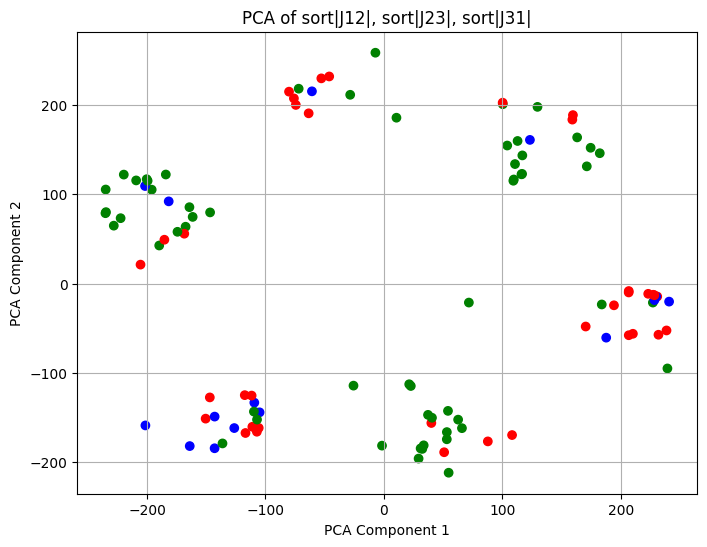

(111, 6)


In [15]:
from sklearn.decomposition import PCA

color_map = {"A" :"red", "B" :"blue", "C" :"green"}
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dataset['family'].map(color_map))
plt.title('PCA of sort|J12|, sort|J23|, sort|J31|')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()
print(X.shape)